## HousePricePrediction

In [1]:
import pandas as pd
import numpy as np

In [2]:
house_data = pd.read_csv("HousePricePrediction.csv")

In [3]:
house_data.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


## Correlation

In [4]:
corr = house_data.corr(numeric_only=True)

print(corr["SalePrice"].sort_values(ascending=False))

SalePrice       1.000000
TotalBsmtSF     0.613581
YearBuilt       0.522897
YearRemodAdd    0.507101
LotArea         0.263843
BsmtFinSF2     -0.011378
Id             -0.021917
OverallCond    -0.077856
MSSubClass     -0.084284
Name: SalePrice, dtype: float64


## Copy

In [5]:
house_data_1= house_data

In [6]:
house_data['SalePrice'].fillna(house_data['SalePrice'].mean(),inplace=True)        

C:\Users\Aditya\AppData\Local\Temp\ipykernel_22316\2363196519.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  house_data['SalePrice'].fillna(house_data['SalePrice'].mean(),inplace=True)


## Droping the null values

In [7]:
house_data.fillna(0, inplace=True)

In [8]:
house_data=pd.get_dummies(house_data)

In [9]:
# CHANGED: Kept OverallCond (removed it from the drop list) as it is a strong numeric predictor.
X = house_data.drop(["Id","BsmtFinSF2","SalePrice","MSSubClass"], axis=1)
Y = house_data["SalePrice"]


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score    


In [11]:
linear = LinearRegression()
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
linear.fit(X_train, Y_train)


print(f"Test R2: {r2_score(Y_test, linear.predict(X_test))}")


Test R2: 0.3028294630349285


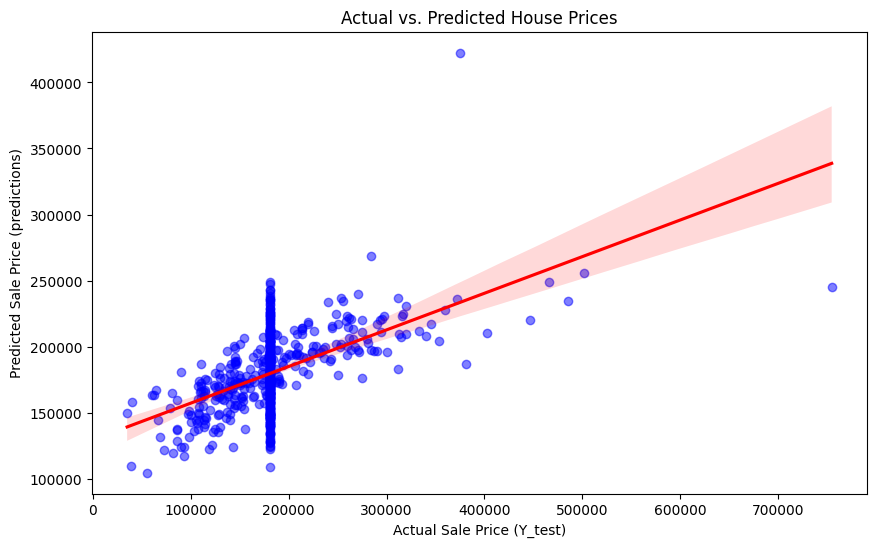

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
predictions = linear.predict(X_test)

plt.figure(figsize=(10, 6))


sns.regplot(x=Y_test, y=predictions, 
            scatter_kws={'alpha':0.5, 'color':'blue'}, 
            line_kws={'color':'red'})                  


plt.title('Actual vs. Predicted House Prices')
plt.xlabel('Actual Sale Price (Y_test)')
plt.ylabel('Predicted Sale Price (predictions)')
plt.show()
